### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from scipy.optimize import linear_sum_assignment
from collections import Counter
from scipy.stats import mode
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Load the Data and Simulation

In [ ]:
# Use the results of LDA CSV files
df = pd.read_csv("df_gz2_under.csv")
X = df.drop('Class', axis=1).values
y = df['Class'].values

In [ ]:
# Split 7-1-2
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=209, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=209, stratify=y_temp
)
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
# Perform KNN on TRAINING data
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_s, y_train)

cluster_train = knn.predict(X_train_s)

print("Cluster:", np.unique(cluster_train))
cluster_val = knn.predict(X_val_s)
cluster_test = knn.predict(X_test_s)

Cluster: [0 1 2]


In [ ]:
# Mapping cluster
cluster_to_class = {}

for cluster in np.unique(cluster_train):
    idx = np.where(cluster_train == cluster)
    majority = mode(y_train[idx], keepdims=True)[0][0]
    cluster_to_class[cluster] = majority

print(cluster_to_class)

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [5]:
y_pred_train = np.vectorize(cluster_to_class.get)(cluster_train)
y_pred_val = np.vectorize(cluster_to_class.get)(cluster_val)
y_pred_test = np.vectorize(cluster_to_class.get)(cluster_test)

In [6]:
cm = confusion_matrix(y_train, cluster_train)

row_ind, col_ind = linear_sum_assignment(-cm)

cluster_map = dict(zip(col_ind, row_ind))

print("Cluster mapping:", cluster_map)

Cluster mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [7]:
cluster_val = knn.predict(X_val_s)
#cluster_val = kmeans.predict(X_val)
cluster_test = knn.predict(X_test_s)
#cluster_test = kmeans.predict(X_test)

In [8]:
y_pred_train = np.vectorize(cluster_map.get)(cluster_train)
y_pred_val = np.vectorize(cluster_map.get)(cluster_val)
y_pred_test = np.vectorize(cluster_map.get)(cluster_test)

<Figure size 600x500 with 0 Axes>

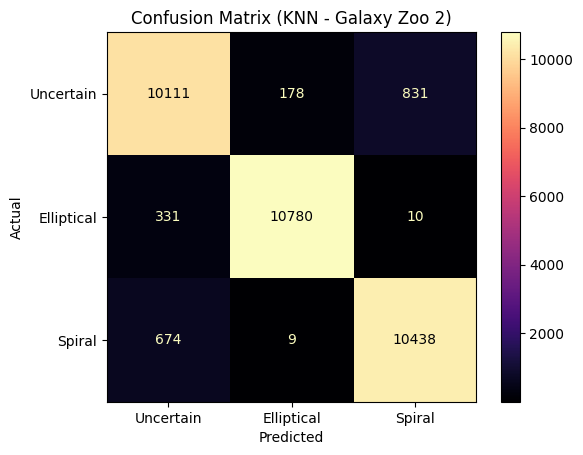

In [10]:
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                            display_labels=['Uncertain', 'Elliptical', 'Spiral'])
disp.plot(cmap='magma', values_format='d')
#sns.heatmap(cm_test,
#            annot=True,
#            cmap="magma",
#            fmt="d")

plt.title("Confusion Matrix (KNN - Galaxy Zoo 2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
prob_test = knn.predict_proba(X_test_s)
prob_val = knn.predict_proba(X_val_s)

In [12]:
classes = np.unique(y_train)

y_test_bin = label_binarize(y_test, classes=classes)
y_val_bin = label_binarize(y_val, classes=classes)

roc_auc = roc_auc_score(
    y_test_bin,
    prob_test,
    multi_class="ovr",
    average="weighted"
)
roc_auc_val = roc_auc_score(
    y_val_bin,
    prob_val,
    multi_class="ovr",
    average="weighted"
)
print("ROC-AUC (OvR):", roc_auc)
print("ROC-AUC (OvR - Validation):", roc_auc_val)

ROC-AUC (OvR): 0.9772894242913306
ROC-AUC (OvR - Validation): 0.9766045173067506


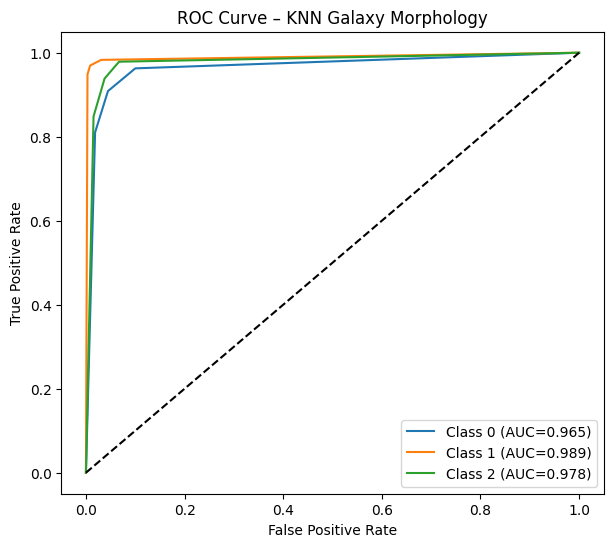

In [13]:
plt.figure(figsize=(7,6))

for i in range(len(classes)):
    
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], prob_test[:,i])
    
    auc = roc_auc_score(y_test_bin[:,i], prob_test[:,i])
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN Galaxy Morphology")

plt.legend()
plt.show()

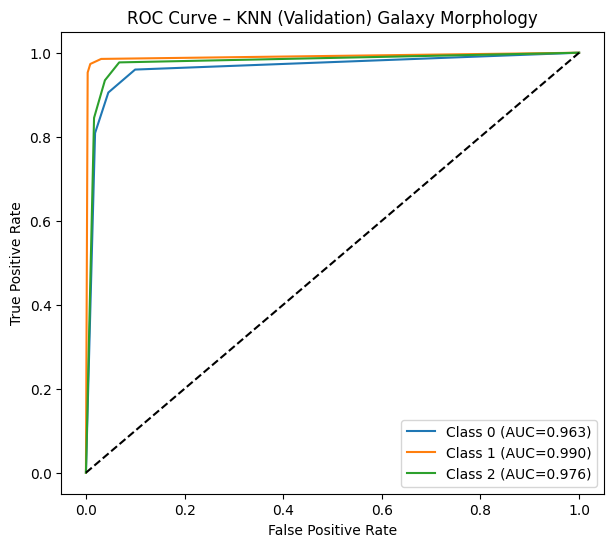

In [14]:
plt.figure(figsize=(7,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_val_bin[:,i], prob_val[:,i])

    auc = roc_auc_score(y_val_bin[:,i], prob_val[:,i])

    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN (Validation) Galaxy Morphology")

plt.legend()
plt.show()

In [15]:
print("Classification Report (KNN-Test)")
print(classification_report(y_test, y_pred_test, digits=4))

Classification Report (KNN-Test)
              precision    recall  f1-score   support

           0     0.9096    0.9093    0.9094     11120
           1     0.9829    0.9693    0.9761     11121
           2     0.9254    0.9386    0.9320     11121

    accuracy                         0.9391     33362
   macro avg     0.9393    0.9391    0.9392     33362
weighted avg     0.9393    0.9391    0.9392     33362



In [16]:
print("Classification Report (KNN-Validation)")
print(classification_report(y_val, y_pred_val, digits=4))

Classification Report (KNN-Validation)
              precision    recall  f1-score   support

           0     0.9081    0.9061    0.9071      5561
           1     0.9822    0.9732    0.9777      5560
           2     0.9239    0.9344    0.9291      5560

    accuracy                         0.9379     16681
   macro avg     0.9381    0.9379    0.9380     16681
weighted avg     0.9381    0.9379    0.9380     16681



In [17]:
hasil = pd.DataFrame(X_test)
hasil.columns = ['LD1', 'LD2']
hasil = pd.concat([hasil, pd.Series(y_pred_test, name='Class')], axis=1)

hasil_centroids = hasil.groupby('Class')[['LD1', 'LD2']].mean()

# Display centroids
print(hasil_centroids)

            LD1       LD2
Class                    
0      0.103180  1.661961
1     -3.295548 -0.777801
2      3.124539 -0.879548


In [ ]:
# Save to results
hasil.to_csv("hasil_gz2_kmeans_under.csv", index=False)

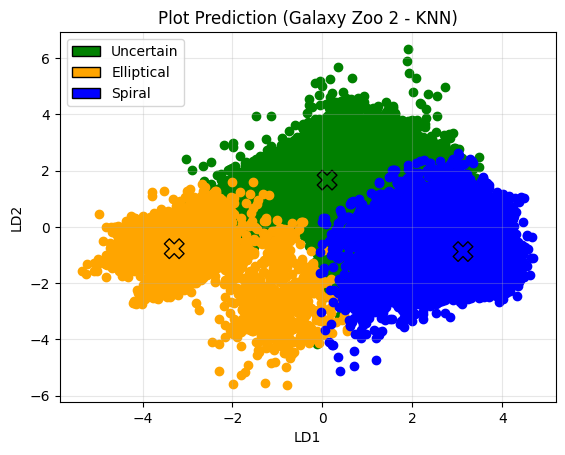

In [18]:
class_names = ['Uncertain', 'Elliptical', 'Spiral']
colors = ['green', 'orange', 'blue']
marker_colors = {1: 'green', 2: 'orange', 3: 'blue'}


for i, class_id in enumerate(sorted(np.unique(hasil["Class"]))):
    mask = hasil["Class"] == class_id
    plt.scatter(hasil[mask]['LD1'], hasil[mask]['LD2'], c=colors[i],
                label=f'{class_names[i]}')

# Plot centroids
plt.scatter(hasil_centroids['LD1'], hasil_centroids['LD2'], 
            c=[marker_colors[1], marker_colors[2], marker_colors[3]], marker='X', s=200, 
            edgecolors='black', linewidth=1)

# Add custom legend for centroids
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=marker_colors[1], edgecolor='black', label='Uncertain'),
                   Patch(facecolor=marker_colors[2], edgecolor='black', label='Elliptical'),
                   Patch(facecolor=marker_colors[3], edgecolor='black', label='Spiral')]
plt.legend(handles=legend_elements)

plt.xlabel(f'LD1')
plt.ylabel(f'LD2')
plt.title('Plot Prediction (Galaxy Zoo 2 - KNN)')
plt.grid(True, alpha=0.3)
plt.show()